# AIS Exploration for ML and STS

Этот ноутбук работает с пайплайном и тремя таблицами:
- `ais_observations`: сырые AIS-наблюдения;
- `vessel_zone_events`: эпизоды нахождения судна в целевых зонах;
- `sts_candidates`: кандидаты на STS по overlap, дистанции, скорости и осадке.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from lng_ml_research.ais_pipeline import AISDatasetBuilder

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 1. Конфигурация источника

Ноутбук работает с `json/jsonl` raw-источниками из `data/raw`. Можно анализировать либо всю папку целиком, либо конкретный файл вроде `ais_observations.jsonl` или `lng_tracker_dataset.json`.


In [2]:
RAW_DIR = ROOT / "data" / "raw"
raw_files = sorted(path.name for path in RAW_DIR.glob("*.json*"))
print("Available JSON/JSONL raw files:")
for file_name in raw_files:
    print(f"- {file_name}")


Available JSON/JSONL raw files:
- ais_observations.jsonl
- lng_tracker_dataset.json
- sts_candidates.jsonl
- vessel_zone_events.jsonl


In [3]:
INPUT_SOURCE = RAW_DIR
# INPUT_SOURCE = RAW_DIR / "ais_observations.jsonl"
# INPUT_SOURCE = RAW_DIR / "lng_tracker_dataset.json"
# INPUT_SOURCE = "https://tankermap.com/api/vessels/live"

builder = AISDatasetBuilder(event_gap_minutes=360, distance_tolerance_minutes=30)


## 2. Построение датасетов

Пайплайн читает совместимые `json/jsonl` файлы из `raw`, строит три таблицы и возвращает краткую сводку по данным.


In [4]:
observations_df, events_df, sts_df, loitering_df, congestion_df, summary = builder.build_all(INPUT_SOURCE)

print(summary)
print(f"observations: {len(observations_df)}")
print(f"events: {len(events_df)}")
print(f"sts candidates: {len(sts_df)}")
print(f"loitering candidates: {len(loitering_df)}")
print(f"congestion windows: {len(congestion_df)}")


{'unique_vessels': 826, 'ais_observations': 9912, 'zone_events': 44, 'active_events': 42, 'completed_events': 2, 'sts_candidates': 673, 'loitering_candidates': 44, 'zone_congestion_windows': 6, 'missing_by_column': {'observed_at': 0, 'mmsi': 0, 'imo': 0, 'latitude': 0, 'longitude': 0, 'speed_knots': 9912, 'draught_meters': 9912, 'zone': 9408}}
observations: 9912
events: 44
sts candidates: 673
loitering candidates: 44
congestion windows: 6


## 3. AIS observations

Смотрим структуру сырого AIS-слоя после нормализации типов и определения зоны.


In [5]:
observations_df.head(10)


,observed_at,vessel_id,name,imo,mmsi,flag,vessel_type,deadweight,latitude,longitude,speed_knots,cog_degrees,draught_meters,nav_status,destination,position_source,zone,date_utc,hour_utc,is_destination_missing,is_speed_missing,is_draught_missing
0,2026-03-27 06:43:13.611996+00:00,NaN,EXCELSIOR LNG,9239616.0,205423000.0,Belgium,Tanker,77287.0,53.62995,8.12838,NaN,NaN,NaN,NaN,NaN,TankerMap AIS,NaN,2026-03-27,6,True,True,True
1,2026-03-27 06:46:30.057066+00:00,NaN,EXCELSIOR LNG,9239616.0,205423000.0,Belgium,Tanker,77287.0,53.62995,8.12838,NaN,NaN,NaN,NaN,NaN,TankerMap AIS,NaN,2026-03-27,6,True,True,True
2,2026-03-27 07:39:36.702264+00:00,NaN,EXCELSIOR LNG,9239616.0,205423000.0,Belgium,Tanker,77287.0,53.62995,8.12838,NaN,NaN,NaN,NaN,NaN,TankerMap AIS,NaN,2026-03-27,7,True,True,True
3,2026-03-27 07:39:48.231046+00:00,NaN,EXCELSIOR LNG,9239616.0,205423000.0,Belgium,Tanker,77287.0,53.62995,8.12838,NaN,NaN,NaN,NaN,NaN,TankerMap AIS,NaN,2026-03-27,7,True,True,True
4,2026-03-27 07:39:59.965230+00:00,NaN,EXCELSIOR LNG,9239616.0,205423000.0,Belgium,Tanker,77287.0,53.62995,8.12838,NaN,NaN,NaN,NaN,NaN,TankerMap AIS,NaN,2026-03-27,7,True,True,True
5,2026-03-27 07:40:11.663187+00:00,NaN,EXCELSIOR LNG,9239616.0,205423000.0,Belgium,Tanker,77287.0,53.62995,8.12838,NaN,NaN,NaN,NaN,NaN,TankerMap AIS,NaN,2026-03-27,7,True,True,True
6,2026-03-27 07:40:23.420595+00:00,NaN,EXCELSIOR LNG,9239616.0,205423000.0,Belgium,Tanker,77287.0,53.62995,8.12838,NaN,NaN,NaN,NaN,NaN,TankerMap AIS,NaN,2026-03-27,7,True,True,True
7,2026-03-27 07:40:35.236173+00:00,NaN,EXCELSIOR LNG,9239616.0,205423000.0,Belgium,Tanker,77287.0,53.62995,8.12838,NaN,NaN,NaN,NaN,NaN,TankerMap AIS,NaN,2026-03-27,7,True,True,True
8,2026-03-27 07:40:46.860992+00:00,NaN,EXCELSIOR LNG,9239616.0,205423000.0,Belgium,Tanker,77287.0,53.62995,8.12838,NaN,NaN,NaN,NaN,NaN,TankerMap AIS,NaN,2026-03-27,7,True,True,True
9,2026-03-27 07:40:58.698140+00:00,NaN,EXCELSIOR LNG,9239616.0,205423000.0,Belgium,Tanker,77287.0,53.62995,8.12838,NaN,NaN,NaN,NaN,NaN,TankerMap AIS,NaN,2026-03-27,7,True,True,True


In [6]:
display(observations_df.info())
display(observations_df.isna().sum().sort_values(ascending=False).to_frame("missing_values"))
display(observations_df["zone"].value_counts(dropna=False).to_frame("count"))


<class 'pandas.DataFrame'>
RangeIndex: 9912 entries, 0 to 9911
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   observed_at             9912 non-null   datetime64[us, UTC]
 1   vessel_id               0 non-null      float64            
 2   name                    9912 non-null   str                
 3   imo                     9912 non-null   float64            
 4   mmsi                    9912 non-null   float64            
 5   flag                    9912 non-null   str                
 6   vessel_type             9912 non-null   str                
 7   deadweight              9912 non-null   float64            
 8   latitude                9912 non-null   float64            
 9   longitude               9912 non-null   float64            
 10  speed_knots             0 non-null      float64            
 11  cog_degrees             0 non-null      float64       

None

,missing_values
vessel_id,9912
cog_degrees,9912
draught_meters,9912
speed_knots,9912
zone,9408
destination,8088
nav_status,5604
flag,0
imo,0
name,0


,count
zone,
NaN,9408
strait_of_malacca,422
gibraltar,46
suez_canal,36


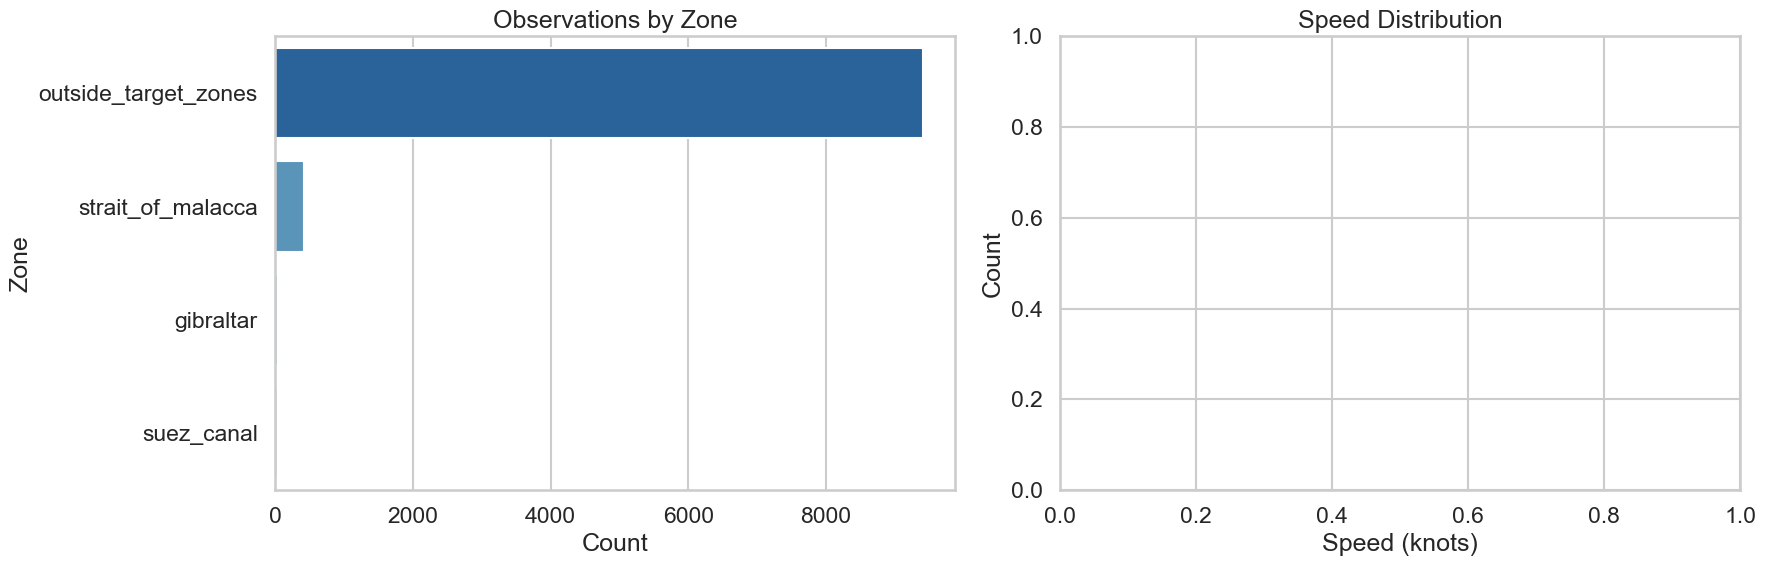

In [7]:
zone_plot_df = observations_df.assign(zone_label=observations_df["zone"].fillna("outside_target_zones"))
zone_order = zone_plot_df["zone_label"].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(
    data=zone_plot_df,
    y="zone_label",
    hue="zone_label",
    order=zone_order,
    hue_order=zone_order,
    ax=axes[0],
    palette="Blues_r",
    legend=False,
)
axes[0].set_title("Observations by Zone")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Zone")

speed_plot_df = observations_df.dropna(subset=["speed_knots"])
sns.histplot(speed_plot_df["speed_knots"], bins=30, kde=True, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Speed Distribution")
axes[1].set_xlabel("Speed (knots)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 4. Zone events

Это event-level слой: один эпизод нахождения судна в зоне подряд.


In [8]:
events_df.head(10)


,event_id,mmsi,imo,name,vessel_id,flag,vessel_type,deadweight,zone,entry_datetime,exit_datetime,observations_count,avg_speed_knots,min_speed_knots,max_speed_knots,avg_draught_meters,min_draught_meters,max_draught_meters,avg_cog_degrees,start_latitude,start_longitude,end_latitude,end_longitude,centroid_latitude,centroid_longitude,position_source,duration_seconds,duration_hours,draught_change_meters,status
0,1,228421700.0,9922988.0,GRAZYNA GESICKA LNG,NaN,France,Tanker,95428.0,suez_canal,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.526675,32.428100,29.526675,32.428100,29.526675,32.428100,TankerMap AIS1,3489.103193,0.969195,NaN,active
1,2,228481700.0,9972218.0,AMARYLLIS KNUTSEN LNG,NaN,France,Tanker,95501.0,gibraltar,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.969720,-5.319942,35.969720,-5.319942,35.969720,-5.319942,TankerMap AIS1,3489.103193,0.969195,NaN,active
2,3,232006298.0,9766554.0,BRITISH CONTRIBUTOR LNG,NaN,United Kingdom (UK),Tanker,94558.0,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.190270,103.685530,1.190410,103.685370,1.190387,103.685395,TankerMap AIS,3489.103193,0.969195,NaN,active
3,4,241352000.0,9658240.0,MARAN GAS TROY LNG,NaN,Greece,Tanker,89240.0,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.300295,103.650755,1.300280,103.650710,1.300283,103.650717,TankerMap AIS1,3489.103193,0.969195,NaN,active
4,5,241414000.0,9701217.0,MARAN GAS AMPHIPOLIS LNG,NaN,Greece,Tanker,95194.0,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.213550,103.496310,1.475990,103.148220,1.432250,103.206235,TankerMap AIS,3489.103193,0.969195,NaN,active
5,6,256056000.0,9333591.0,COOL RIDER LNG,NaN,Malta,Tanker,84303.0,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.202600,103.668480,1.203150,103.667930,1.203070,103.668009,TankerMap AIS,3489.103193,0.969195,NaN,active
6,7,310495000.0,9267015.0,LNG BENUE LNG,NaN,Bermuda,Tanker,82971.0,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.454310,103.876760,1.454350,103.876760,1.454343,103.876760,TankerMap AIS,3489.103193,0.969195,NaN,active
7,8,310772000.0,9748899.0,GASLOG HOUSTON LNG,NaN,Bermuda,Tanker,92345.0,gibraltar,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.178730,-5.138390,36.081290,-5.354710,36.097530,-5.318657,TankerMap AIS,3489.103193,0.969195,NaN,active
8,9,310779000.0,9744025.0,GASLOG GLADSTONE LNG,NaN,Bermuda,Tanker,87955.0,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.157890,103.730040,1.157480,103.729450,1.157547,103.729545,TankerMap AIS,3489.103193,0.969195,NaN,active
9,10,310806000.0,9864928.0,GASLOG GALVESTON LNG,NaN,Bermuda,Tanker,88136.0,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.450650,103.877040,1.451715,103.878465,1.451537,103.878227,TankerMap AIS,3489.103193,0.969195,NaN,active


In [9]:
event_summary = (
    events_df.groupby("zone", dropna=False)
    .agg(
        events=("zone", "size"),
        unique_vessels=("mmsi", "nunique"),
        avg_duration_hours=("duration_hours", "mean"),
        median_duration_hours=("duration_hours", "median"),
        avg_speed_knots=("avg_speed_knots", "mean"),
        avg_draught_change=("draught_change_meters", "mean"),
    )
    .sort_values("events", ascending=False)
)

event_summary


,events,unique_vessels,avg_duration_hours,median_duration_hours,avg_speed_knots,avg_draught_change
zone,,,,,,
strait_of_malacca,37,37,0.894357,0.969195,NaN,NaN
gibraltar,4,4,0.734259,0.969195,NaN,NaN
suez_canal,3,3,0.969195,0.969195,NaN,NaN


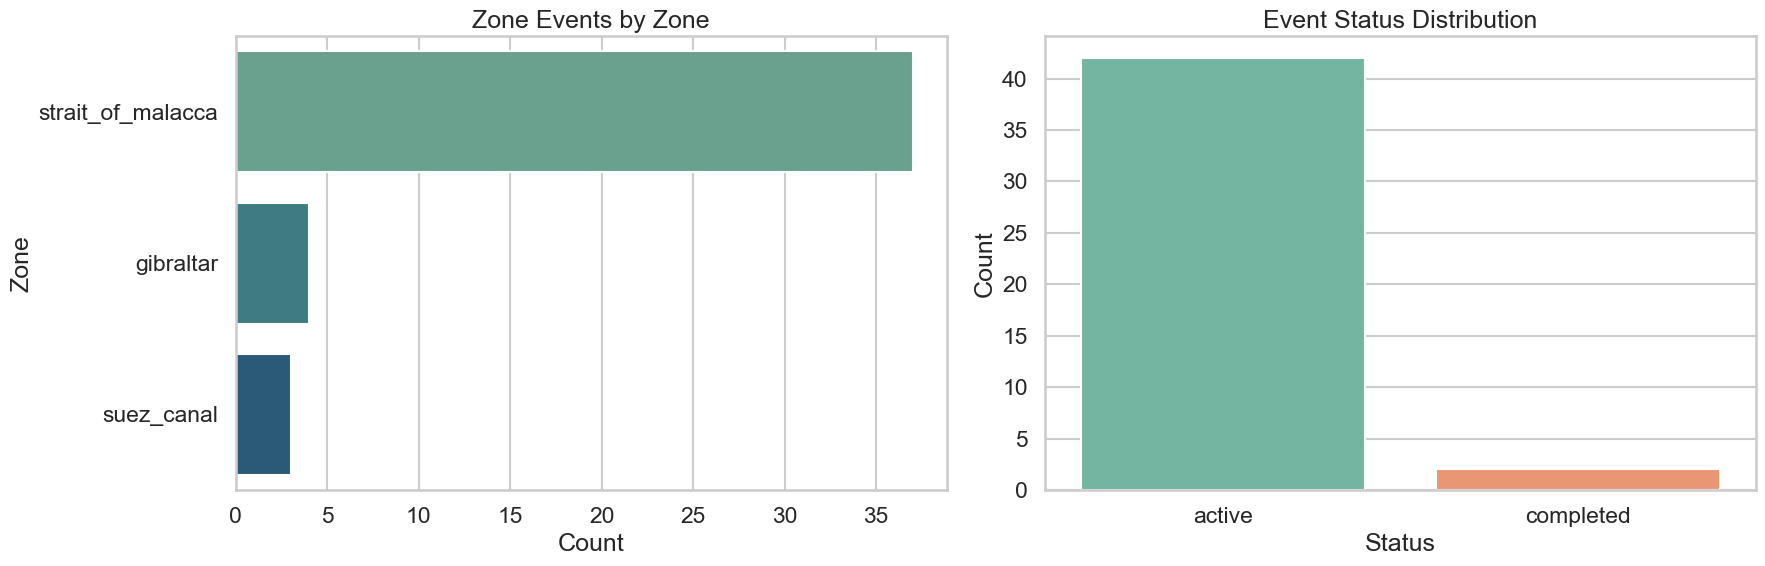

In [10]:
zone_order = events_df["zone"].value_counts().index
status_order = events_df["status"].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(
    data=events_df,
    y="zone",
    hue="zone",
    order=zone_order,
    hue_order=zone_order,
    ax=axes[0],
    palette="crest",
    legend=False,
)
axes[0].set_title("Zone Events by Zone")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Zone")

sns.countplot(
    data=events_df,
    x="status",
    hue="status",
    order=status_order,
    hue_order=status_order,
    ax=axes[1],
    palette="Set2",
    legend=False,
)
axes[1].set_title("Event Status Distribution")
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


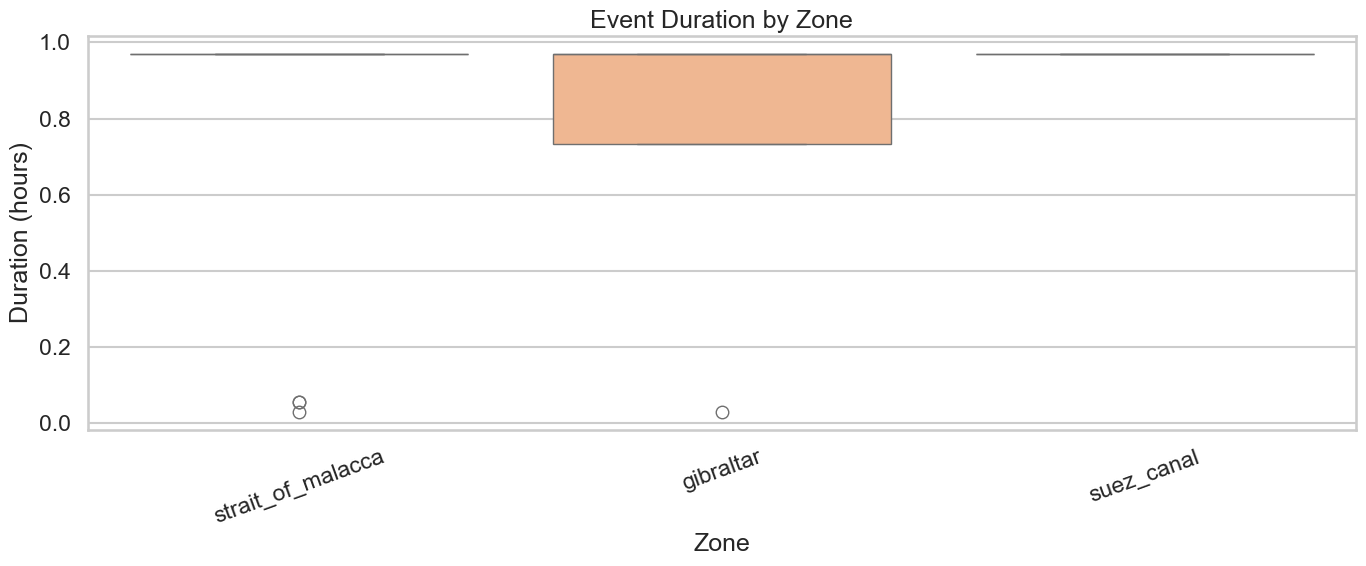

In [11]:
zone_order = events_df["zone"].value_counts().index

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=events_df,
    x="zone",
    y="duration_hours",
    hue="zone",
    order=zone_order,
    hue_order=zone_order,
    palette="pastel",
    legend=False,
)
plt.title("Event Duration by Zone")
plt.xlabel("Zone")
plt.ylabel("Duration (hours)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 5. STS candidates

`sts_candidates` считаются не только по overlap во времени, но и с учётом дистанции между судами, средней скорости и изменения осадки.


In [12]:
sts_df.head(15)


,vessel_a_mmsi,vessel_b_mmsi,vessel_a_name,vessel_b_name,zone,overlap_start,overlap_end,overlap_seconds,overlap_hours,avg_distance_nm,min_distance_nm,vessel_a_avg_speed,vessel_b_avg_speed,vessel_a_draught_change,vessel_b_draught_change,sts_score
0,563216800.0,538011214.0,HOEGH GANDRIA LNG,FUJI LNG LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,3489.103193,0.969195,0.001455,0.001119,NaN,NaN,NaN,NaN,0.849933
1,431778000.0,525701066.0,PACIFIC MIMOSA LNG,LADY EVA LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,3489.103193,0.969195,0.082162,0.081305,NaN,NaN,NaN,NaN,0.845122
2,241352000.0,525701066.0,MARAN GAS TROY LNG,LADY EVA LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,3489.103193,0.969195,0.129306,0.129193,NaN,NaN,NaN,NaN,0.842248
3,533937000.0,310495000.0,SERI AMANAH LNG,LNG BENUE LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,3489.103193,0.969195,0.146914,0.146863,NaN,NaN,NaN,NaN,0.841188
4,310495000.0,310806000.0,LNG BENUE LNG,GASLOG GALVESTON LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,3489.103193,0.969195,0.193748,0.188420,NaN,NaN,NaN,NaN,0.838695
5,241352000.0,431778000.0,MARAN GAS TROY LNG,PACIFIC MIMOSA LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,3489.103193,0.969195,0.191656,0.190352,NaN,NaN,NaN,NaN,0.838579
6,636025820.0,533920000.0,NILA LNG,PUTERI MUTIARA SATU LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,3489.103193,0.969195,0.257787,0.257787,NaN,NaN,NaN,NaN,0.834533
7,533937000.0,310806000.0,SERI AMANAH LNG,GASLOG GALVESTON LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,3489.103193,0.969195,0.301501,0.289398,NaN,NaN,NaN,NaN,0.832636
8,538007985.0,654311424.0,SINGAPORE ENERGY LNG,LNGT KARADENIZ LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,3489.103193,0.969195,0.471201,0.471201,NaN,NaN,NaN,NaN,0.821728
9,538008352.0,311001874.0,MERCHANT LNG,SEAPEAK HISPANIA LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,3489.103193,0.969195,0.483471,0.483471,NaN,NaN,NaN,NaN,0.820992


In [13]:
sts_df.describe(include="all").transpose()


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
vessel_a_mmsi,673.0,NaN,NaN,NaN,487916823.575037,228421700.0,525114138.0,538004983.0,563162500.0,654311424.0,123187461.512859
vessel_b_mmsi,673.0,NaN,NaN,NaN,466183139.167905,241352000.0,311001874.0,525701066.0,538002921.0,654311424.0,123283253.574409
vessel_a_name,673,41,BRITISH CONTRIBUTOR LNG,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vessel_b_name,673,41,LNGT KARADENIZ LNG,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,673,3,strait_of_malacca,664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overlap_start,673,NaN,NaN,NaN,2026-03-27 06:46:19.606557+00:00,2026-03-27 06:43:13.611996+00:00,2026-03-27 06:43:13.611996+00:00,2026-03-27 06:43:13.611996+00:00,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:39:36.702264+00:00,NaN
overlap_end,673,NaN,NaN,NaN,2026-03-27 07:35:45.132112+00:00,2026-03-27 06:46:30.057066+00:00,2026-03-27 07:41:22.715189+00:00,2026-03-27 07:41:22.715189+00:00,2026-03-27 07:41:22.715189+00:00,2026-03-27 07:41:22.715189+00:00,NaN
overlap_seconds,673.0,NaN,NaN,NaN,2965.525555,106.012925,3489.103193,3489.103193,3489.103193,3489.103193,1211.95339
overlap_hours,673.0,NaN,NaN,NaN,0.823757,0.029448,0.969195,0.969195,0.969195,0.969195,0.336654
avg_distance_nm,673.0,NaN,NaN,NaN,130.120072,0.001455,19.744297,117.827236,157.07784,479.657453,127.341357


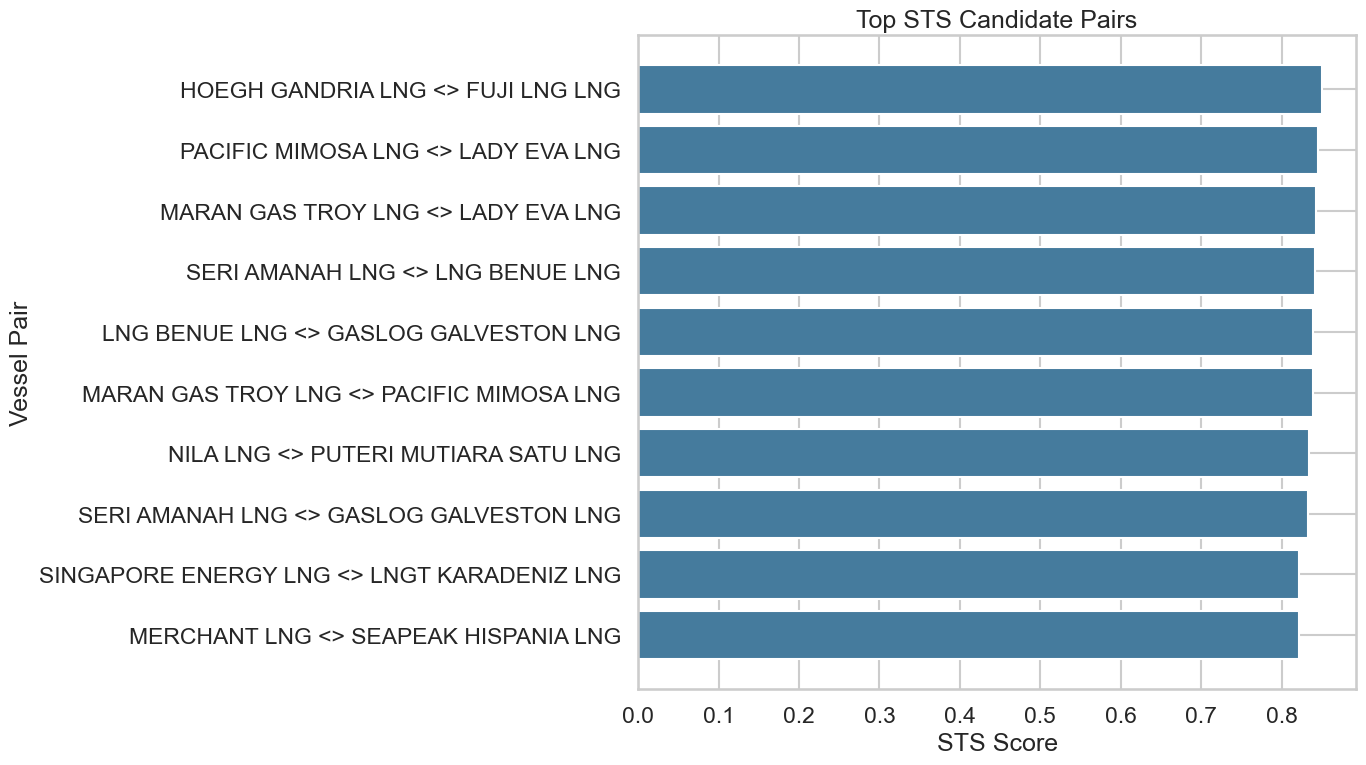

In [14]:
if not sts_df.empty:
    plot_sts = sts_df.head(10).copy().iloc[::-1]
    plot_sts["pair"] = plot_sts["vessel_a_name"] + " <> " + plot_sts["vessel_b_name"]

    plt.figure(figsize=(14, 8))
    plt.barh(plot_sts["pair"], plot_sts["sts_score"], color="#457b9d")
    plt.title("Top STS Candidate Pairs")
    plt.xlabel("STS Score")
    plt.ylabel("Vessel Pair")
    plt.tight_layout()
    plt.show()
else:
    print("No STS candidates were found for the current data and thresholds.")


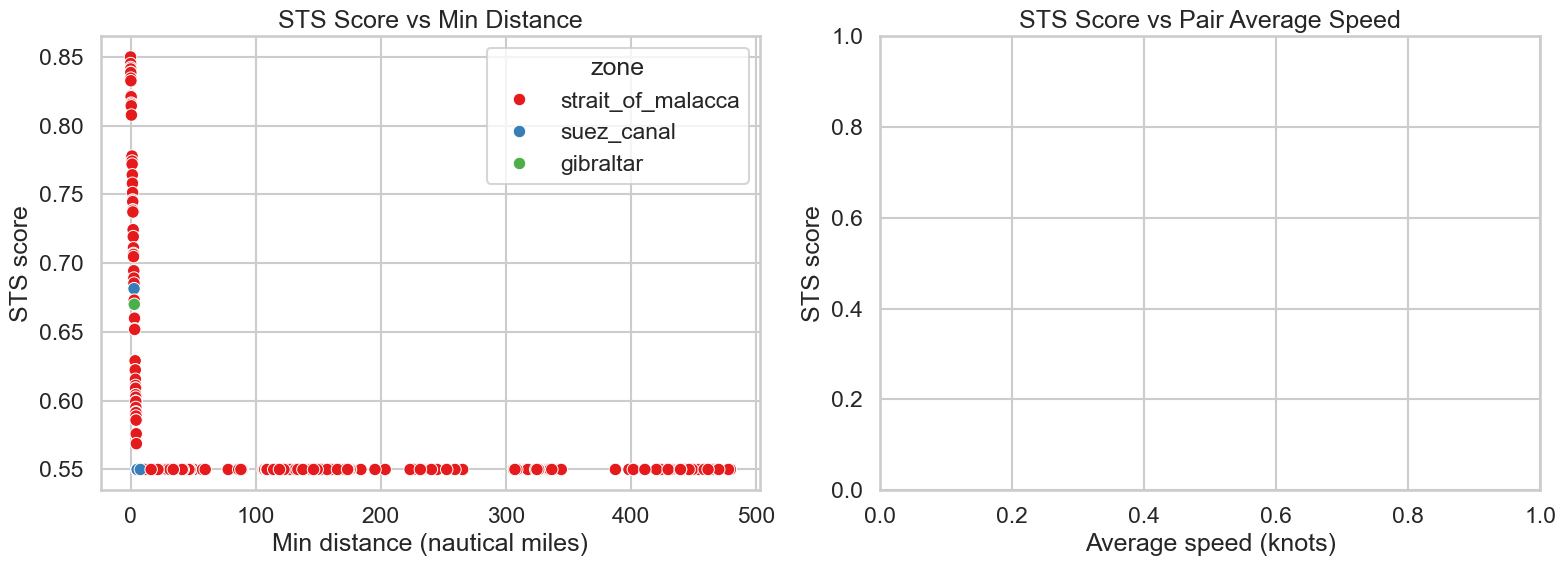

In [15]:
if not sts_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(
        data=sts_df,
        x="min_distance_nm",
        y="sts_score",
        hue="zone",
        ax=axes[0],
        palette="Set1",
    )
    axes[0].set_title("STS Score vs Min Distance")
    axes[0].set_xlabel("Min distance (nautical miles)")
    axes[0].set_ylabel("STS score")

    sts_df_plot = sts_df.copy()
    sts_df_plot["pair_avg_speed"] = (sts_df_plot["vessel_a_avg_speed"] + sts_df_plot["vessel_b_avg_speed"]) / 2
    sns.scatterplot(
        data=sts_df_plot,
        x="pair_avg_speed",
        y="sts_score",
        hue="zone",
        ax=axes[1],
        palette="Set1",
    )
    axes[1].set_title("STS Score vs Pair Average Speed")
    axes[1].set_xlabel("Average speed (knots)")
    axes[1].set_ylabel("STS score")

    plt.tight_layout()
    plt.show()
else:
    print("STS scatter plots skipped because sts_df is empty.")


## 6. Loitering candidates

Слой `loitering_candidates` ранжирует события, где судно дольше обычного находится в зоне и при этом движется медленно.


In [16]:
loitering_df.head(15)


,mmsi,imo,name,zone,entry_datetime,exit_datetime,status,duration_seconds,duration_hours,avg_speed_knots,observations_count,draught_change_meters,zone_duration_median_hours,zone_avg_speed_median_knots,duration_vs_zone_median,is_low_speed,is_long_duration,loitering_score
0,228421700.0,9922988.0,GRAZYNA GESICKA LNG,suez_canal,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,active,3489.103193,0.969195,NaN,12,0.0,0.969195,NaN,1.0,True,False,0.44
1,228481700.0,9972218.0,AMARYLLIS KNUTSEN LNG,gibraltar,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,active,3489.103193,0.969195,NaN,12,0.0,0.969195,NaN,1.0,True,False,0.44
2,232006298.0,9766554.0,BRITISH CONTRIBUTOR LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,active,3489.103193,0.969195,NaN,12,0.0,0.969195,NaN,1.0,True,False,0.44
3,241352000.0,9658240.0,MARAN GAS TROY LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,active,3489.103193,0.969195,NaN,12,0.0,0.969195,NaN,1.0,True,False,0.44
4,241414000.0,9701217.0,MARAN GAS AMPHIPOLIS LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,active,3489.103193,0.969195,NaN,12,0.0,0.969195,NaN,1.0,True,False,0.44
5,256056000.0,9333591.0,COOL RIDER LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,active,3489.103193,0.969195,NaN,12,0.0,0.969195,NaN,1.0,True,False,0.44
6,310495000.0,9267015.0,LNG BENUE LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,active,3489.103193,0.969195,NaN,12,0.0,0.969195,NaN,1.0,True,False,0.44
7,310772000.0,9748899.0,GASLOG HOUSTON LNG,gibraltar,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,active,3489.103193,0.969195,NaN,12,0.0,0.969195,NaN,1.0,True,False,0.44
8,310779000.0,9744025.0,GASLOG GLADSTONE LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,active,3489.103193,0.969195,NaN,12,0.0,0.969195,NaN,1.0,True,False,0.44
9,310806000.0,9864928.0,GASLOG GALVESTON LNG,strait_of_malacca,2026-03-27 06:43:13.611996+00:00,2026-03-27 07:41:22.715189+00:00,active,3489.103193,0.969195,NaN,12,0.0,0.969195,NaN,1.0,True,False,0.44


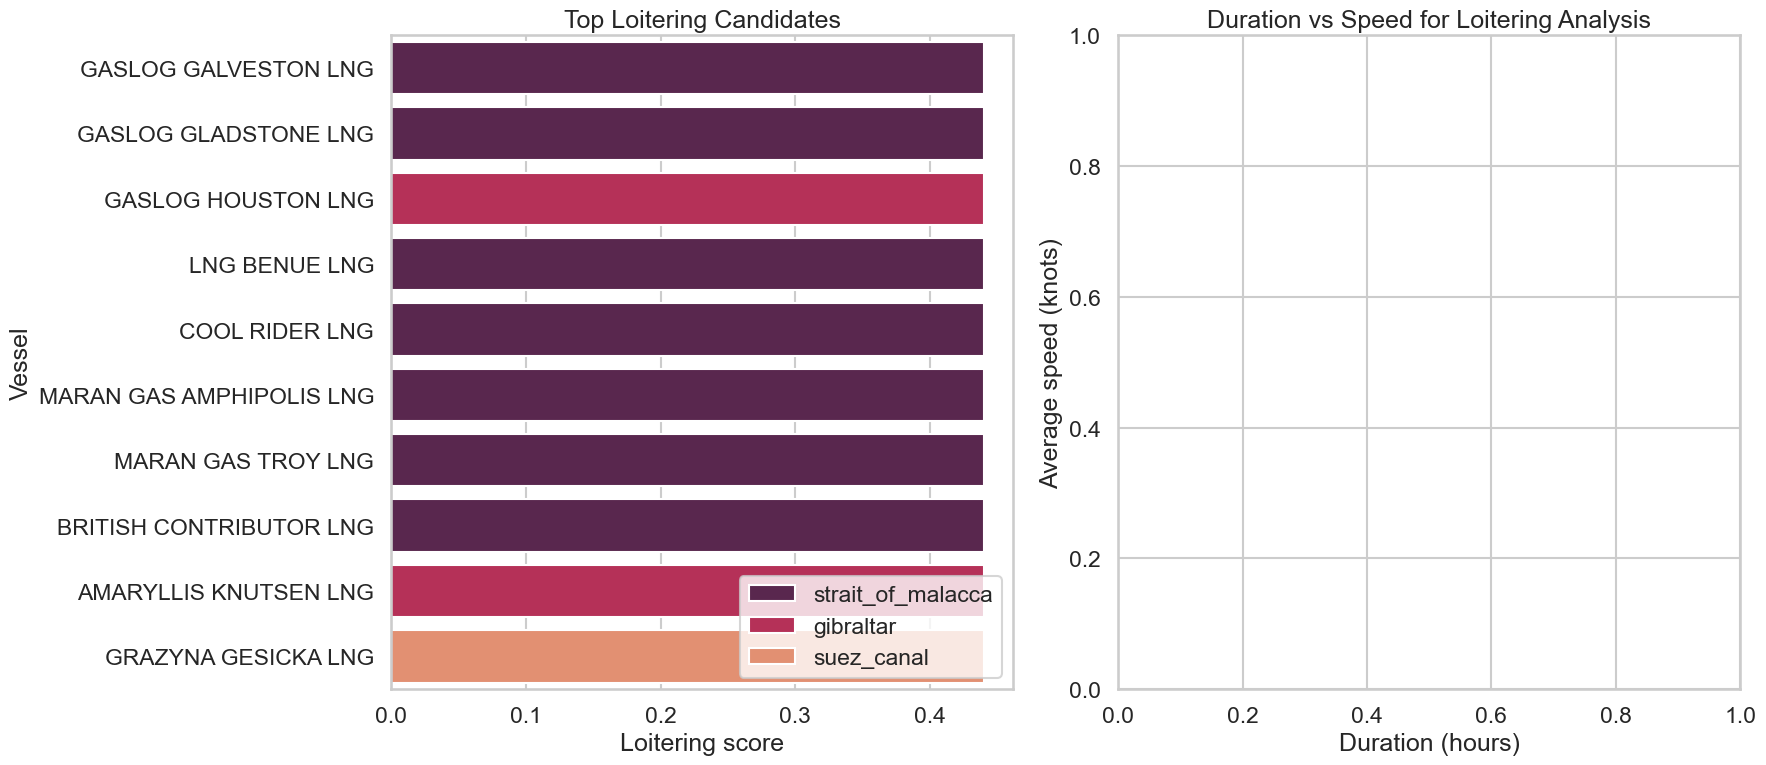

In [17]:
if not loitering_df.empty:
    plot_loitering = loitering_df.head(10).copy().iloc[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    sns.barplot(data=plot_loitering, x="loitering_score", y="name", hue="zone", dodge=False, ax=axes[0], palette="rocket")
    axes[0].set_title("Top Loitering Candidates")
    axes[0].set_xlabel("Loitering score")
    axes[0].set_ylabel("Vessel")
    axes[0].legend(loc="lower right")

    sns.scatterplot(data=loitering_df, x="duration_hours", y="avg_speed_knots", size="loitering_score", hue="zone", ax=axes[1], palette="Set2")
    axes[1].set_title("Duration vs Speed for Loitering Analysis")
    axes[1].set_xlabel("Duration (hours)")
    axes[1].set_ylabel("Average speed (knots)")

    plt.tight_layout()
    plt.show()
else:
    print("No loitering candidates were found for the current data.")


## 7. Zone congestion

Слой `zone_congestion` показывает, в какие часы зона была наиболее загружена по числу судов, наблюдений и замедлению трафика.


In [18]:
congestion_df.head(15)


,zone,observed_hour,observation_count,unique_vessels,avg_speed_knots,median_speed_knots,event_count,avg_event_duration_hours,median_event_duration_hours,active_events,congestion_score
0,strait_of_malacca,2026-03-27 07:00:00+00:00,350,35,NaN,NaN,1.0,0.029448,0.029448,1.0,0.9875
1,strait_of_malacca,2026-03-27 06:00:00+00:00,72,36,NaN,NaN,36.0,0.918383,0.969195,34.0,0.7220
2,gibraltar,2026-03-27 07:00:00+00:00,40,4,NaN,NaN,1.0,0.029448,0.029448,1.0,0.2900
3,suez_canal,2026-03-27 07:00:00+00:00,30,3,NaN,NaN,0.0,0.000000,0.000000,0.0,0.2675
4,gibraltar,2026-03-27 06:00:00+00:00,6,3,NaN,NaN,3.0,0.969195,0.969195,3.0,0.2435
5,suez_canal,2026-03-27 06:00:00+00:00,6,3,NaN,NaN,3.0,0.969195,0.969195,3.0,0.2435


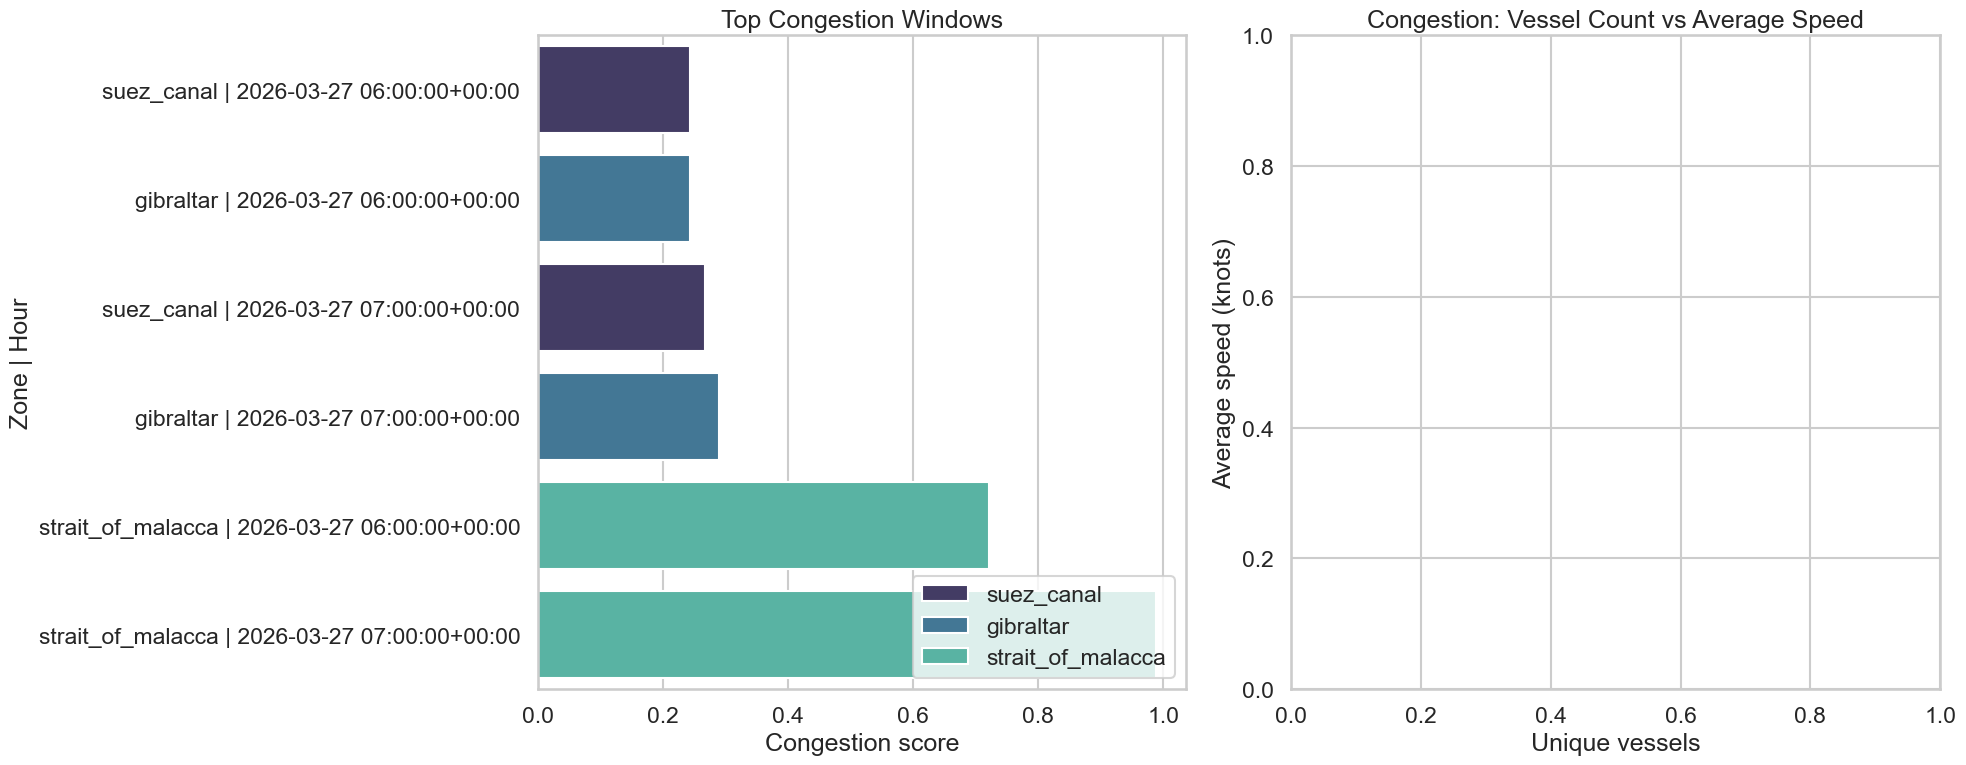

In [19]:
if not congestion_df.empty:
    plot_congestion = congestion_df.head(12).copy().iloc[::-1]
    plot_congestion["window"] = plot_congestion["zone"] + " | " + plot_congestion["observed_hour"].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sns.barplot(data=plot_congestion, x="congestion_score", y="window", hue="zone", dodge=False, ax=axes[0], palette="mako")
    axes[0].set_title("Top Congestion Windows")
    axes[0].set_xlabel("Congestion score")
    axes[0].set_ylabel("Zone | Hour")
    axes[0].legend(loc="lower right")

    sns.scatterplot(data=congestion_df, x="unique_vessels", y="avg_speed_knots", size="congestion_score", hue="zone", ax=axes[1], palette="tab10")
    axes[1].set_title("Congestion: Vessel Count vs Average Speed")
    axes[1].set_xlabel("Unique vessels")
    axes[1].set_ylabel("Average speed (knots)")

    plt.tight_layout()
    plt.show()
else:
    print("No congestion windows were found for the current data.")


## 6. Сохранение результатов

Если нужно, можно сохранить построенные таблицы в `data/processed`. Ниже запрашивается `parquet`, но если в окружении нет `pyarrow` или `fastparquet`, код автоматически сохранит результаты в CSV.


In [20]:
OUTPUT_DIR = ROOT / "data" / "processed"
paths = builder.write_outputs(observations_df, events_df, sts_df, loitering_df, congestion_df, OUTPUT_DIR, output_format="parquet")
paths


{'observations': WindowsPath('e:/funny/lng-ml-research/data/processed/ais_observations.csv'),
 'events': WindowsPath('e:/funny/lng-ml-research/data/processed/vessel_zone_events.csv'),
 'sts': WindowsPath('e:/funny/lng-ml-research/data/processed/sts_candidates.csv'),
 'loitering': WindowsPath('e:/funny/lng-ml-research/data/processed/loitering_candidates.csv'),
 'congestion': WindowsPath('e:/funny/lng-ml-research/data/processed/zone_congestion.csv')}

## 7. Что можно улучшить дальше

- копить исторические snapshots по расписанию, а не анализировать один вызов API;
- заменить bounding boxes зон на полигоны;
- добавить anomaly detection уже на `vessel_zone_events`;
- учитывать course variability, low-speed ratio и near-stationary ratio прямо в `sts_score`.
